# Batch environments and scan rollouts

CPU companion; no accelerator is required. TPU execution not validated.

- Build a scan over vmapped transitions with explicit key ownership.
- Reconstruct episode returns and reward-to-go from padded trajectories.
- Verify the live-transition mask and distinguish batch dimensions from time dimensions.

One episode is easy to inspect, but an agent needs many experiences. How do we collect a batch without mixing time, environments or random streams? We will turn the previous transition into a fixed-shape rollout and prove that its padded rows cannot become training evidence.

## The idea

Batched rollouts put independent environments on one axis and time on another. Some environments finish earlier, so masks describe which transitions remain meaningful while arrays keep fixed shapes.

## Keep the array shape fixed while activity changes

Draw one environment per row and time across columns. Mark the transition that terminates an episode, then mark later padding separately. The terminal transition can still earn reward; masking it out too early loses part of the episode.

Carry the next state and activity information explicitly. If the implementation resets finished environments, distinguish that contract from absorbing padding instead of mixing them in one explanation.

The active-count curve decreases while the tensor shape stays fixed. It measures active environments, not shrinking allocation. Verify one environment independently, then permute the batch to check that unrelated trajectories stay independent.

### A terminal transition still counts

**Predict:** Should every cell after the first done flag be treated identically to the transition that caused done?

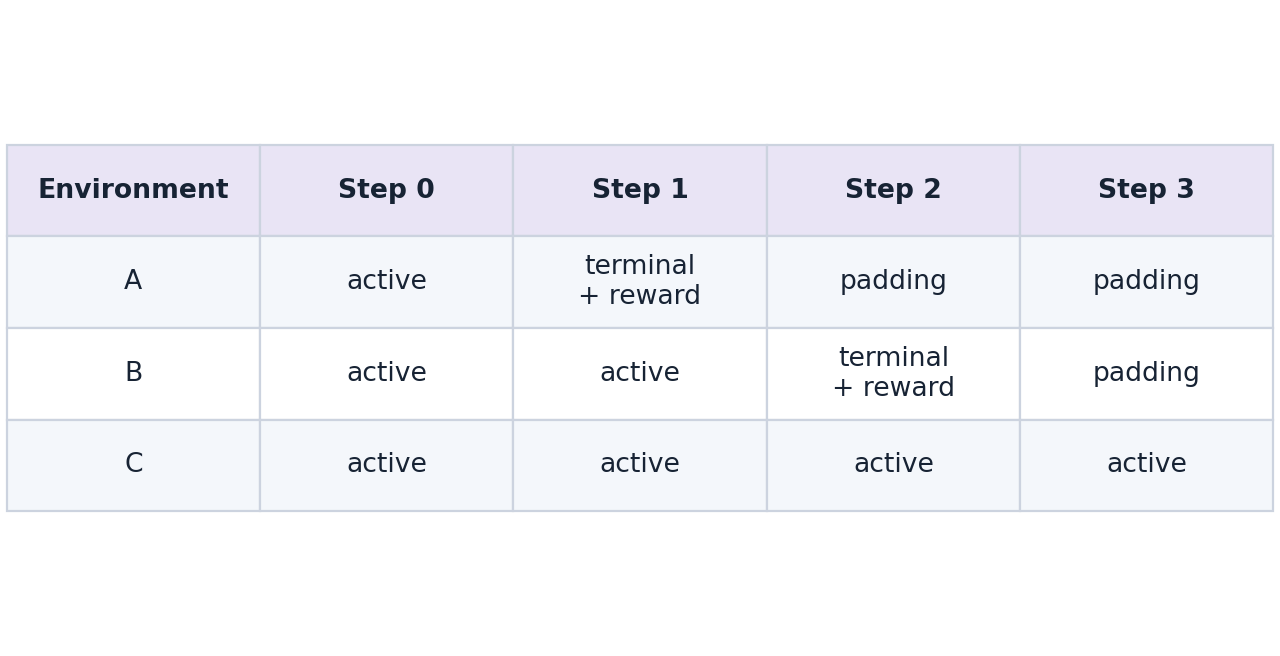

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Each row is one environment. A terminating transition can still earn reward; later cells are padding under this absorbing-state contract. Tensor length stays fixed while activity changes. This is a conceptual rollout example, not an auto-reset implementation.

### Pause and reason

Should every cell after the first done flag be treated identically to the transition that caused done?

<details><summary>Compare your reasoning</summary>

No. The terminating transition can contain valid reward and learning information. Later padding follows the declared terminal policy and should not invent extra transitions.

</details>

## Give each axis one meaning

For $T=8$ and $B=64$, the reward array has shape $(8,64)$. Summing axis zero gives one return per episode. Summing axis one gives total reward at each time index across the batch, a different statistic. vmap maps reset and step over environments; scan threads the complete batch of states through time. The carry has the same structure, shapes and dtypes at every iteration.

## Split randomness where ownership changes

First split a reset key from an action key. Split reset keys across the $B$ environments. Split action keys across the $T$ time steps, then across environments. A scalar reset key broadcast to all environments would create correlated starts. An action key reused at every step would replay draws. Deterministic transitions do not need an extra key, so their signature stays simple.

## Store the behavior policy before changing it

Each position has a policy logit $\theta_s$. Applying the sigmoid gives the probability of moving right; the left probability is its complement. A sampled action is discrete, so we will not differentiate through action sampling. Instead, we store its log probability under the behavior policy. Stable log-sigmoid avoids taking a logarithm of a probability rounded to zero.

$$
\pi_\theta(1\mid s)=\sigma(\theta_s),\qquad \log\pi_\theta(a\mid s)=a\log\sigma(\theta_s)+(1-a)\log\sigma(-\theta_s)
$$

## A final transition is still a learning example

The active mask is computed from the state before step. Therefore the action that reaches the goal is active and retains its reward. Only subsequent rows are padding. Masking with the next state would delete the successful action itself. We store the final observation in the returned state and do not replace it with a fresh start. This collector handles one finite episode per environment, not an endless auto-reset stream.

## Credit each action with rewards that follow it

Reward-to-go sums rewards from the current time onward. For rewards $(-0.01,-0.01,1,0)$, targets are $(0.98,0.99,1,0)$. The first action can influence all later rewards; the last successful action is credited with the goal reward only. We reverse the time axis, take a cumulative sum, and reverse it back. There is no value bootstrap here because these are complete finite-horizon episodes.

$$
G_{t,b}=\sum_{u=t}^{T-1}r_{u,b}
$$

## Reuse the verified environment

Create main.py with this block. Run python3 main.py in the course CPU environment.

In [1]:
"""Finite-horizon tabular policy training. CPU teaching environment, not a benchmark."""
from functools import partial
from typing import NamedTuple
import jax
import jax.numpy as jnp
import numpy as np


class State(NamedTuple):
    position: jax.Array
    elapsed: jax.Array
    done: jax.Array


def reset(key):
    """Start uniformly at position 0 or 1; goal is position 3."""
    return State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))


def step(state, action, horizon=8):
    """Action 0: left, 1: right. Caller supplies binary action and positive horizon.

    Returns next state, reward, termination event, truncation event. Finished
    states absorb without more rewards/events. No implicit reset or lost final observation.
    """
    active = ~state.done
    proposed = jnp.clip(state.position + 2 * action - 1, 0, 3)
    position = jnp.where(active, proposed, state.position)
    elapsed = state.elapsed + active.astype(jnp.int32)
    terminated = active & (position == 3)
    truncated = active & ~terminated & (elapsed >= horizon)
    reward = jnp.where(active, jnp.where(terminated, 1., -.01), 0.)
    return State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated

Keep the state and ending contract identical to the previous lesson.

## Collect a batch and compute targets

Append this block to main.py. Run python3 main.py in the course CPU environment.

In [2]:
def log_probability(theta, observations, actions):
    logits = theta[jnp.minimum(observations, 2)]
    return jnp.where(actions == 1, jax.nn.log_sigmoid(logits), jax.nn.log_sigmoid(-logits))


@partial(jax.jit, static_argnames=('batch_size', 'horizon'))
def rollout(theta, key, batch_size=256, horizon=8):
    reset_key, action_key = jax.random.split(key)
    states = jax.vmap(reset)(jax.random.split(reset_key, batch_size))
    time_keys = jax.random.split(action_key, horizon)
    def body(states, time_key):
        observations = states.position
        keys = jax.random.split(time_key, batch_size)
        probabilities = jax.nn.sigmoid(theta[jnp.minimum(observations, 2)])
        actions = jax.vmap(jax.random.bernoulli)(keys, probabilities).astype(jnp.int32)
        next_states, rewards, terminated, truncated = jax.vmap(
            lambda s, a: step(s, a, horizon))(states, actions)
        record = dict(observation=observations, action=actions, reward=rewards,
                      active=~states.done, terminated=terminated, truncated=truncated,
                      old_logp=log_probability(theta, observations, actions))
        return next_states, record
    final, records = jax.lax.scan(body, states, time_keys)
    return final, records


def returns_to_go(rewards):
    """Undiscounted finite-episode objective; rewards after done are already zero."""
    return jnp.cumsum(rewards[::-1], axis=0)[::-1]

scan emits time-major arrays; vmap keeps environments independent within each time step.

## Check shapes and episode boundaries

Append this block to main.py. Run python3 main.py in the course CPU environment.

In [3]:
theta = jnp.zeros(3)
final, records = rollout(theta, jax.random.key(5), batch_size=64, horizon=8)
assert records['reward'].shape == (8, 64)
assert bool(final.done.all())
assert bool(jnp.all(jnp.sum(records['terminated'] | records['truncated'], axis=0) == 1))
assert bool(jnp.all(jnp.where(records['active'], 0., records['reward']) == 0.))
episode_returns = records['reward'].sum(axis=0)
print('return mean:', float(episode_returns.mean()))
print('active environments by transition:', records['active'].sum(axis=1))

return mean: 0.5848437547683716
active environments by transition: [64 64 58 53 47 44 39 29]


Exactly one ending event and zero padded rewards are stronger checks than a plausible mean return.

## Run the example

In [4]:
"""Finite-horizon tabular policy training. CPU teaching environment, not a benchmark."""
from functools import partial
from typing import NamedTuple
import jax
import jax.numpy as jnp
import numpy as np


class State(NamedTuple):
    position: jax.Array
    elapsed: jax.Array
    done: jax.Array


def reset(key):
    """Start uniformly at position 0 or 1; goal is position 3."""
    return State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))


def step(state, action, horizon=8):
    """Action 0: left, 1: right. Caller supplies binary action and positive horizon.

    Returns next state, reward, termination event, truncation event. Finished
    states absorb without more rewards/events. No implicit reset or lost final observation.
    """
    active = ~state.done
    proposed = jnp.clip(state.position + 2 * action - 1, 0, 3)
    position = jnp.where(active, proposed, state.position)
    elapsed = state.elapsed + active.astype(jnp.int32)
    terminated = active & (position == 3)
    truncated = active & ~terminated & (elapsed >= horizon)
    reward = jnp.where(active, jnp.where(terminated, 1., -.01), 0.)
    return State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated

def log_probability(theta, observations, actions):
    logits = theta[jnp.minimum(observations, 2)]
    return jnp.where(actions == 1, jax.nn.log_sigmoid(logits), jax.nn.log_sigmoid(-logits))


@partial(jax.jit, static_argnames=('batch_size', 'horizon'))
def rollout(theta, key, batch_size=256, horizon=8):
    reset_key, action_key = jax.random.split(key)
    states = jax.vmap(reset)(jax.random.split(reset_key, batch_size))
    time_keys = jax.random.split(action_key, horizon)
    def body(states, time_key):
        observations = states.position
        keys = jax.random.split(time_key, batch_size)
        probabilities = jax.nn.sigmoid(theta[jnp.minimum(observations, 2)])
        actions = jax.vmap(jax.random.bernoulli)(keys, probabilities).astype(jnp.int32)
        next_states, rewards, terminated, truncated = jax.vmap(
            lambda s, a: step(s, a, horizon))(states, actions)
        record = dict(observation=observations, action=actions, reward=rewards,
                      active=~states.done, terminated=terminated, truncated=truncated,
                      old_logp=log_probability(theta, observations, actions))
        return next_states, record
    final, records = jax.lax.scan(body, states, time_keys)
    return final, records


def returns_to_go(rewards):
    """Undiscounted finite-episode objective; rewards after done are already zero."""
    return jnp.cumsum(rewards[::-1], axis=0)[::-1]

theta = jnp.zeros(3)
final, records = rollout(theta, jax.random.key(5), batch_size=64, horizon=8)
assert records['reward'].shape == (8, 64)
assert bool(final.done.all())
assert bool(jnp.all(jnp.sum(records['terminated'] | records['truncated'], axis=0) == 1))
assert bool(jnp.all(jnp.where(records['active'], 0., records['reward']) == 0.))
episode_returns = records['reward'].sum(axis=0)
print('return mean:', float(episode_returns.mean()))
print('active environments by transition:', records['active'].sum(axis=1))

return mean: 0.5848437547683716
active environments by transition: [64 64 58 53 47 44 39 29]


Expected: The trajectory has the stated time and environment axes, exactly one ending event per episode, and zero reward on every padded row.

## The live batch shrinks while the array shape stays fixed

Predict: Should every row contain the same number of active environments?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind':'line','x':list(range(1,9)),'xlabel':'transition index','ylabel':'active environments before transition','series':[{'label':'uniform random policy','y':records['active'].sum(1).tolist()}]}

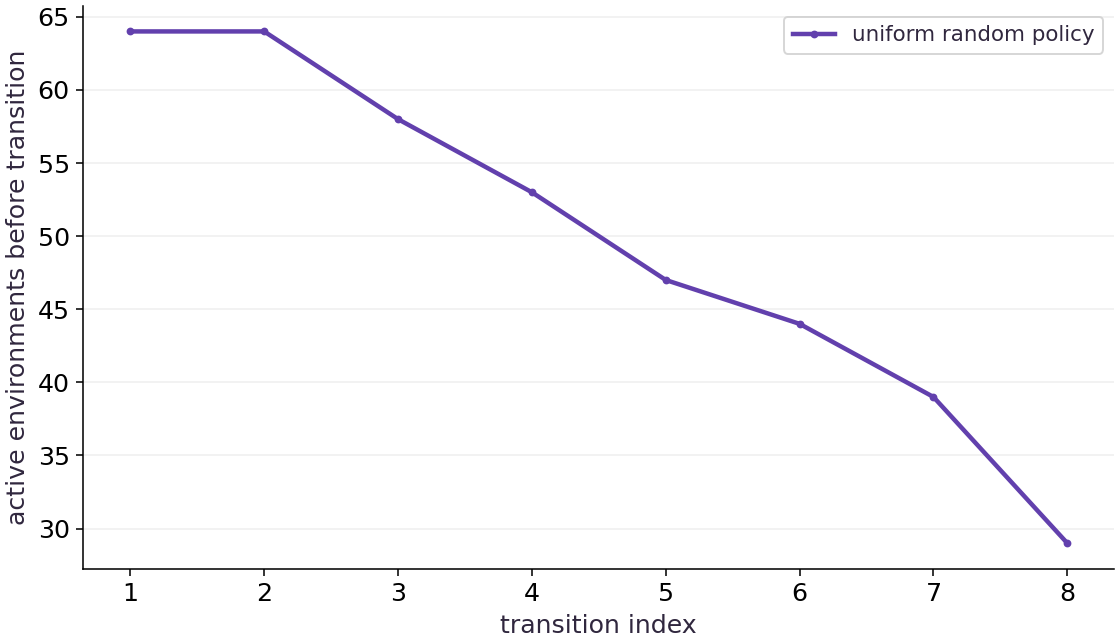

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the transition index; the vertical axis counts environments active before that transition. The first value is $64$. The count never rises because we do not reset inside a rollout. Decreases show episodes reaching the goal; episodes still active on the final row will either finish or time out on that row. In the recorded seed, the first two counts are both $64$: even the nearer starting position needs two actions to reach the goal. The third count is $58$, and the last is $29$. The unchanged first pair is therefore expected, not a stalled loop.

### Connect it to the computation

This curve is not reward or policy quality: a fast-ending policy could succeed, fail or exploit a termination bug in a different task. Here the transition tests establish that early endings are goals. The fixed $(8,64)$ reward array retains later rows, but their active flags are false. Changing the seed can move individual counts while preserving these invariants.

## Replay the entire collector

Predict: Does replay require restoring only the environment state?

In [7]:
again = rollout(theta, jax.random.key(5), 64, 8)[1]
for name in records:
    assert jnp.array_equal(records[name], again[name])
changed = rollout(theta, jax.random.key(6), 64, 8)[1]
assert not jnp.array_equal(records['action'], changed['action'])

Expected: Every field replays for the same configuration and key; another key changes actions.

The random stream is part of the experiment state. Replay in this environment is not a promise of identical outputs across arbitrary library versions or devices.

## Reward-to-go by hand

Predict: Predict the four targets for rewards $(-0.01,-0.01,1,0)$.

In [8]:
r = jnp.array([[-.01],[-.01],[1.],[0.]])
g = returns_to_go(r)
assert jnp.allclose(g[:,0], jnp.array([.98,.99,1.,0.]))
print('reward-to-go:', g[:,0])

reward-to-go: [0.98 0.99 1.   0.  ]


Expected: The targets are $(0.98,0.99,1,0)$.

Zero padded rewards preserve the finite-episode sum, while the active mask removes meaningless log probabilities.

## Your exercise

Change the batch to $7$ environments and the horizon to $5$. Verify array shapes, one ending event per episode and zero rewards after finishing.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
final7, r7 = rollout(theta, jax.random.key(17), 7, 5)
assert r7['reward'].shape == (5,7)
assert bool(final7.done.all())
assert jnp.array_equal((r7['terminated'] | r7['truncated']).sum(0), jnp.ones(7))
assert bool(jnp.all(jnp.where(r7['active'],0.,r7['reward']) == 0.))

## Catch a shifted mask · Transfer / diagnosis

Construct a two-action success from position $1$. Compare masking by the pre-transition done flag with masking by the post-transition done flag.

Hint: Record the mask before calling step; the successful transition still belongs to the episode.

In [11]:
# Write your attempt here.

## Reference reasoning

The broken mask removes the action responsible for success, leaving only a cost.

In [12]:
s = State(jnp.int32(1),jnp.int32(0),jnp.bool_(False))
correct, broken = 0., 0.
for a in [1,1]:
    active = ~s.done
    s, reward, _, _ = step(s,jnp.int32(a))
    correct += float(reward*active)
    broken += float(reward*(~s.done))
assert abs(correct-.99) < 1e-6
assert abs(broken+.01) < 1e-6

## Check a deterministic policy limit · Transfer / diagnosis

Use very large positive logits and verify that every episode follows a shortest route.

Hint: The two start states need different numbers of actions. Compare each return against its own initial position.

In [13]:
# Write your attempt here.

## Reference reasoning

The expected return is calculated from the initial position rather than copied from the collector.

In [14]:
_, easy = rollout(jnp.full(3,100.),jax.random.key(42),23,8)
expected = jnp.where(easy['observation'][0] == 0,.98,.99)
assert jnp.allclose(easy['reward'].sum(0),expected,atol=1e-6)
assert jnp.array_equal(easy['active'].sum(0),3-easy['observation'][0])

## Checkpoint

Which axis should be summed to obtain one return per environment from a time-major reward array?

1. The time axis
2. The environment axis
3. Both axes before averaging by live transitions

## Diagnose

If reported return changes merely by padding an already finished trajectory, inspect reward masking. If success disappears from the objective, check whether active was recorded before step. If trajectories match too often, inspect broadcast or reused keys before increasing the batch.

## Evidence

Keep reconstructed trajectories, randomized keys, padding masks and independent return calculations. Show how a changed key affects interaction without changing the environment rules.

## Carry forward

- vmap handles independent environments; scan handles the dependent time sequence.
- Store behavior log probabilities and live-transition masks with rewards.

## Primary references

- [JAX: explicit pseudorandom keys](https://docs.jax.dev/en/latest/random-numbers.html)
- [JAX scan: fixed-shape carry](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [Schulman et al.: Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)
- [Gymnasium: termination and truncation](https://gymnasium.farama.org/tutorials/gymnasium_basics/handling_time_limits/)